In [26]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / "src").exists() else cwd.parent
sys.path.insert(0, str(repo_root / "src"))

from vislearnlabpy.embeddings.generate_embeddings import EmbeddingGenerator, EmbeddingConfig
from vislearnlabpy.embeddings.embedding_store import EmbeddingStore
from vislearnlabpy.embeddings.utils import display_search_results, zscore_embeddings, filter_embeddings
import numpy as np

In [27]:
# Update these here to reflect in the rest of the file. You can leave these as they are for default behavior
OUTPUT_DIRECTORY = None
INPUT_CSV = None # For example: '/ccn2/dataset/babyview/outputs_20250312/yoloe_cdi_100k_cropped_by_class/cropped_images_summary.csv'
INPUT_DIRECTORY = None
OVERWRITE = True
BATCH_SIZE = 1 # how many images are being processed in one go
SAVE_EVERY_BATCH = True
OUTPUT_TYPE = "doc" # options are "doc" for docarray, "npy" for numpys, "csv" for numbers in a csv
IMAGE_DIR = '/Volumes/vislearnlab/data/THINGS-dataset/object_images_CC0'
EMBEDDING_DIR = '/Volumes/vislearnlab/data/THINGS-dataset/thingsplus_embeddings'

# Load Models

In [28]:
config = EmbeddingConfig(device="cpu", output_type="doc")
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

generators = {}
model_names = [
    "clip",
    "clip-hf-large",
    "dinov3-babyview",
    "dinov3",
    "dinov2",
    "dino_say_vitl16", 
    "dino_s_vitl16",
    "dino_ego4d-200h_vitb14",
    "dino_imagenet100_vitb14"
]

for name in model_names:
    print(f"Loading {name}...")
    generators[name] = EmbeddingGenerator.from_model(name, device="cpu", output_type="doc")


Loading clip...
Loading clip-hf-large...


Loading weights: 100%|██████████| 590/590 [00:00<00:00, 8834.94it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading dinov3-babyview...


Loading weights: 100%|██████████| 439/439 [00:00<00:00, 9397.45it/s]


Loading dinov3...


Loading weights: 100%|██████████| 415/415 [00:00<00:00, 9303.29it/s]


Loading dinov2...


Loading weights: 100%|██████████| 439/439 [00:00<00:00, 9601.25it/s]


Loading dino_say_vitl16...
Take key teacher in provided checkpoint dict
Pretrained weights found at /Users/alexanderchin/.cache/huggingface/hub/models--eminorhan--dino_say_vitl16/snapshots/dbb305c6a30e182d9305631a45c4cb81674d50df/dino_say_vitl16.pth and loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v'])
Loading dino_s_vitl16...
Take key teacher in provided checkpoint dict
Pretrained weights found at /Users/alexanderchin/.cache/huggingface/hub/models--eminorhan--dino_s_vitl16/snapshots/a2f3f90cf5c3a35cafda6d6bb03d325887f003dc/dino_s_vitl16.pth and loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v'])
Loadin

In [10]:
print(generators.keys())

dict_keys(['clip', 'clip-hf-large', 'dinov3-babyview', 'dinov3', 'dinov2', 'dino_say_vitl16', 'dino_s_vitl16', 'dino_ego4d-200h_vitb14', 'dino_imagenet100_vitb14'])


In [11]:
store_paths = {
    "clip": "clip_image_embeddings_doc.docs",
    "clip-hf-large": "clip-large_image_embeddings_doc.docs",
    "dinov3-babyview": "dinov3-bv_image_embeddings_doc.docs",
    "dinov3": "dinov3-vitl16_image_embeddings_doc.docs",
    "dinov2": "dinov2-l_image_embeddings_doc.docs",
    "dino_say_vitl16": "dino_say_vitl16_image_embeddings_doc.docs",
    "dino_s_vitl16": "dino_s_vitl16_image_embeddings_doc.docs",
    "dino_ego4d-200h_vitb14": "dino_ego4d-200h_vitb14_image_embeddings_doc.docs",
    "dino_imagenet100_vitb14": "dino_imagenet100_vitb14_image_embeddings_doc.docs",
}

# Generate image embeddings for each model on the partial THINGS dataset

In [ ]:
#Can skip this block if images are already embedded

for name, generator in generators.items():
    print(f"Generating embeddings for {name}...")
    generator.generate_image_embeddings(input_dir=IMAGE_DIR, batch_size=BATCH_SIZE)

# Optional save embeddings as npy

In [ ]:
#clip_generator.output_type = 'npy'
#clip_generator.config.save_every_batch = SAVE_EVERY_BATCH
#clip_generator.generate_image_embeddings(input_csv="input/inputs.csv", overwrite=OVERWRITE, batch_size=BATCH_SIZE)

#for name, generator in generators.items():
#    if name == "clip":
#        continue
#    generator.output_type = 'npy'
#    generator.config.save_every_batch = SAVE_EVERY_BATCH
#    generator.generate_image_embeddings(input_csv="input/inputs.csv", overwrite=OVERWRITE, batch_size=BATCH_SIZE)

In [14]:

clip_embedding_store = EmbeddingStore.from_doc(f"{EMBEDDING_DIR}/clip_image_embeddings_doc.docs", feature_generator=generators["clip"])
bv_embedding_store = EmbeddingStore.from_doc(f"{EMBEDDING_DIR}/dinov3-bv_image_embeddings_doc.docs", feature_generator=generators["dinov3-babyview"])
dinov3_embedding_store = EmbeddingStore.from_doc(f"{EMBEDDING_DIR}/dinov3-vitl16_image_embeddings_doc.docs", feature_generator=generators["dinov3"])
dinov2_embedding_store = EmbeddingStore.from_doc(f"{EMBEDDING_DIR}/dinov2-l_image_embeddings_doc.docs", feature_generator=generators["dinov2"])
dino_say_embedding_store = EmbeddingStore.from_doc(f"{EMBEDDING_DIR}/dino_say_vitl16_image_embeddings_doc.docs", feature_generator=generators["dino_say_vitl16"])
dino_s_embedding_store = EmbeddingStore.from_doc(f"{EMBEDDING_DIR}/dino_s_vitl16_image_embeddings_doc.docs", feature_generator=generators["dino_s_vitl16"])
ego_embedding_store = EmbeddingStore.from_doc(f"{EMBEDDING_DIR}/dino_ego4d-200h_vitb14_image_embeddings_doc.docs", feature_generator=generators["dino_ego4d-200h_vitb14"])
imagenet_embedding_store = EmbeddingStore.from_doc(f"{EMBEDDING_DIR}/dino_imagenet100_vitb14_image_embeddings_doc.docs", feature_generator=generators["dino_imagenet100_vitb14"])
clip_hf_embedding_store = EmbeddingStore.from_doc(f"{EMBEDDING_DIR}/clip-large_image_embeddings_doc.docs", feature_generator=generators["clip-hf-large"])

/opt/miniconda3/envs/vislearnlabpy/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

## Searching through embeddings

## z-score column-wise

In [15]:
clip_embedding_store.EmbeddingList.normed_embedding = zscore_embeddings(np.stack(clip_embedding_store.EmbeddingList.embedding))
bv_embedding_store.EmbeddingList.normed_embedding = zscore_embeddings(np.stack(bv_embedding_store.EmbeddingList.embedding))

dinov3_embedding_store.EmbeddingList.normed_embedding = zscore_embeddings(np.stack(dinov3_embedding_store.EmbeddingList.embedding))
dinov2_embedding_store.EmbeddingList.normed_embedding = zscore_embeddings(np.stack(dinov2_embedding_store.EmbeddingList.embedding))
dino_say_embedding_store.EmbeddingList.normed_embedding = zscore_embeddings(np.stack(dino_say_embedding_store.EmbeddingList.embedding))
dino_s_embedding_store.EmbeddingList.normed_embedding = zscore_embeddings(np.stack(dino_s_embedding_store.EmbeddingList.embedding))
ego_embedding_store.EmbeddingList.normed_embedding = zscore_embeddings(np.stack(ego_embedding_store.EmbeddingList.embedding))
imagenet_embedding_store.EmbeddingList.normed_embedding = zscore_embeddings(np.stack(imagenet_embedding_store.EmbeddingList.embedding))
clip_hf_embedding_store.EmbeddingList.normed_embedding = zscore_embeddings(np.stack(clip_hf_embedding_store.EmbeddingList.embedding))


## Compute RDMs

In [17]:
from vislearnlabpy.embeddings.similarity_utils import compute_rdm, plot_rdm, correlate_rdms

rdms = {}
rdms_no_rank = {}

models = [
    ("clip", f"{EMBEDDING_DIR}/clip_image_embeddings_doc.docs"),
    ("clip-hf-large", f"{EMBEDDING_DIR}/clip-large_image_embeddings_doc.docs"),
    ("dinov3-babyview", f"{EMBEDDING_DIR}/dinov3-bv_image_embeddings_doc.docs"),
    ("dinov3", f"{EMBEDDING_DIR}/dinov3-vitl16_image_embeddings_doc.docs"),
    ("dinov2", f"{EMBEDDING_DIR}/dinov2-l_image_embeddings_doc.docs"),
    ("dino_say_vitl16", f"{EMBEDDING_DIR}/dino_say_vitl16_image_embeddings_doc.docs"),
    ("dino_s_vitl16",f"{EMBEDDING_DIR}/dino_s_vitl16_image_embeddings_doc.docs"),
    ("dino_ego4d-200h_vitb14", f"{EMBEDDING_DIR}/dino_ego4d-200h_vitb14_image_embeddings_doc.docs"),
    ("dino_imagenet100_vitb14", f"{EMBEDDING_DIR}/dino_imagenet100_vitb14_image_embeddings_doc.docs"),
]

for pair in models:
    name, store_path = pair
    generator = generators[name]
    # Load store to get embeddings
    store = EmbeddingStore.from_doc(store_path, feature_generator=generator)
    
    # Use cosine for CLIP, euclidean for DINO models
    method = "cosine" if "clip" in name else "euclidean"
    
    emb_stack = np.stack(store.EmbeddingList.embedding)
    rdms[name] = compute_rdm(emb_stack, method=method, ranked=True)
    rdms_no_rank[name] = compute_rdm(emb_stack, method=method, ranked=False)


# Export RDMs

In [18]:
import os
from vislearnlabpy.embeddings.similarity_utils import plot_rdm


for pair in models:
    name, _ = pair
    out_dir = f"output_{name}"
    
    # ranked
    plot_rdm(out_dir, rdms[name])
    os.rename(os.path.join(out_dir, "rdm.png"), os.path.join(out_dir, "rdm_ranked.png"))
    
    # unranked
    plot_rdm(out_dir, rdms_no_rank[name])
    os.rename(os.path.join(out_dir, "rdm.png"), os.path.join(out_dir, "rdm_unranked.png"))

    print(f"Saved RDM for {name} at {os.path.join(out_dir, 'rdm_ranked.png')}")

Saved RDM for clip at output_clip/rdm_ranked.png
Saved RDM for clip-hf-large at output_clip-hf-large/rdm_ranked.png
Saved RDM for dinov3-babyview at output_dinov3-babyview/rdm_ranked.png
Saved RDM for dinov3 at output_dinov3/rdm_ranked.png
Saved RDM for dinov2 at output_dinov2/rdm_ranked.png
Saved RDM for dino_say_vitl16 at output_dino_say_vitl16/rdm_ranked.png
Saved RDM for dino_s_vitl16 at output_dino_s_vitl16/rdm_ranked.png
Saved RDM for dino_ego4d-200h_vitb14 at output_dino_ego4d-200h_vitb14/rdm_ranked.png
Saved RDM for dino_imagenet100_vitb14 at output_dino_imagenet100_vitb14/rdm_ranked.png


In [23]:
import pandas as pd
import numpy as np
from tqdm import tqdm

stores = {
    "clip": clip_embedding_store,
    "bv": bv_embedding_store,
    "dinov3": dinov3_embedding_store,
    "dinov2": dinov2_embedding_store,
    "say": dino_say_embedding_store,
    "s": dino_s_embedding_store,
    "ego": ego_embedding_store,
    "imagenet": imagenet_embedding_store,
}

methods = {
    "_Cor": "correlation",
    "_Euc": "euclidean",
    "_Cos": "cosine",
}

variants = {
    "raw": "embedding",
    "z":   "normed_embedding",
}

keys = [f"{s}{m}" for s in stores.keys() for m in methods.keys()]

for s_name, store in stores.items():
    print(s_name, len(store.EmbeddingList.embedding))

all_rdms = {v: {} for v in variants}
all_corr = {}

for v_name, attr in variants.items():
    print(f"\n=== {v_name} ({attr}) ===")
    rdms = all_rdms[v_name]

    for s_name, store in tqdm(stores.items(), desc=f"Computing RDMs ({v_name})"):
        emb = np.stack(getattr(store.EmbeddingList, attr))
        for m_abbr, m_name in methods.items():
            key = f"{s_name}{m_abbr}"
            print(f"  Computing RDM: {key} ({m_name})")
            rdms[key] = compute_rdm(emb, method=m_name)

    df_corr = pd.DataFrame(index=keys, columns=keys, dtype=float)
    total_pairs = len(keys) * len(keys)
    with tqdm(total=total_pairs, desc=f"Correlating RDMs ({v_name})") as pbar:
        for k1 in keys:
            for k2 in keys:
                pbar.set_postfix_str(f"{k1} vs {k2}")
                if k1 == k2:
                    df_corr.loc[k1, k2] = 1.0
                else:
                    df_corr.loc[k1, k2] = correlate_rdms(
                        rdms[k1], rdms[k2], correlation="spearman"
                    )
                pbar.update(1)
    all_corr[v_name] = df_corr

df_corr_raw = all_corr["raw"]
df_corr_z   = all_corr["z"]

clip 1854
bv 1854
dinov3 1854
dinov2 1854
say 1854
s 1854
ego 1854
imagenet 1854

=== raw (embedding) ===


Computing RDMs (raw):   0%|          | 0/8 [00:00<?, ?it/s]

  Computing RDM: clip_Cor (correlation)
  Computing RDM: clip_Euc (euclidean)


Computing RDMs (raw):  12%|█▎        | 1/8 [00:00<00:01,  4.37it/s]

  Computing RDM: clip_Cos (cosine)
  Computing RDM: bv_Cor (correlation)
  Computing RDM: bv_Euc (euclidean)


...

Computing RDMs (z):  88%|████████▊ | 7/8 [00:02<00:00,  2.55it/s]

  Computing RDM: ego_Cos (cosine)
  Computing RDM: imagenet_Cor (correlation)
  Computing RDM: imagenet_Euc (euclidean)


Computing RDMs (z): 100%|██████████| 8/8 [00:03<00:00,  2.63it/s]


  Computing RDM: imagenet_Cos (cosine)


Correlating RDMs (z): 100%|██████████| 576/576 [03:09<00:00,  3.03it/s, imagenet_Cos vs imagenet_Cos]


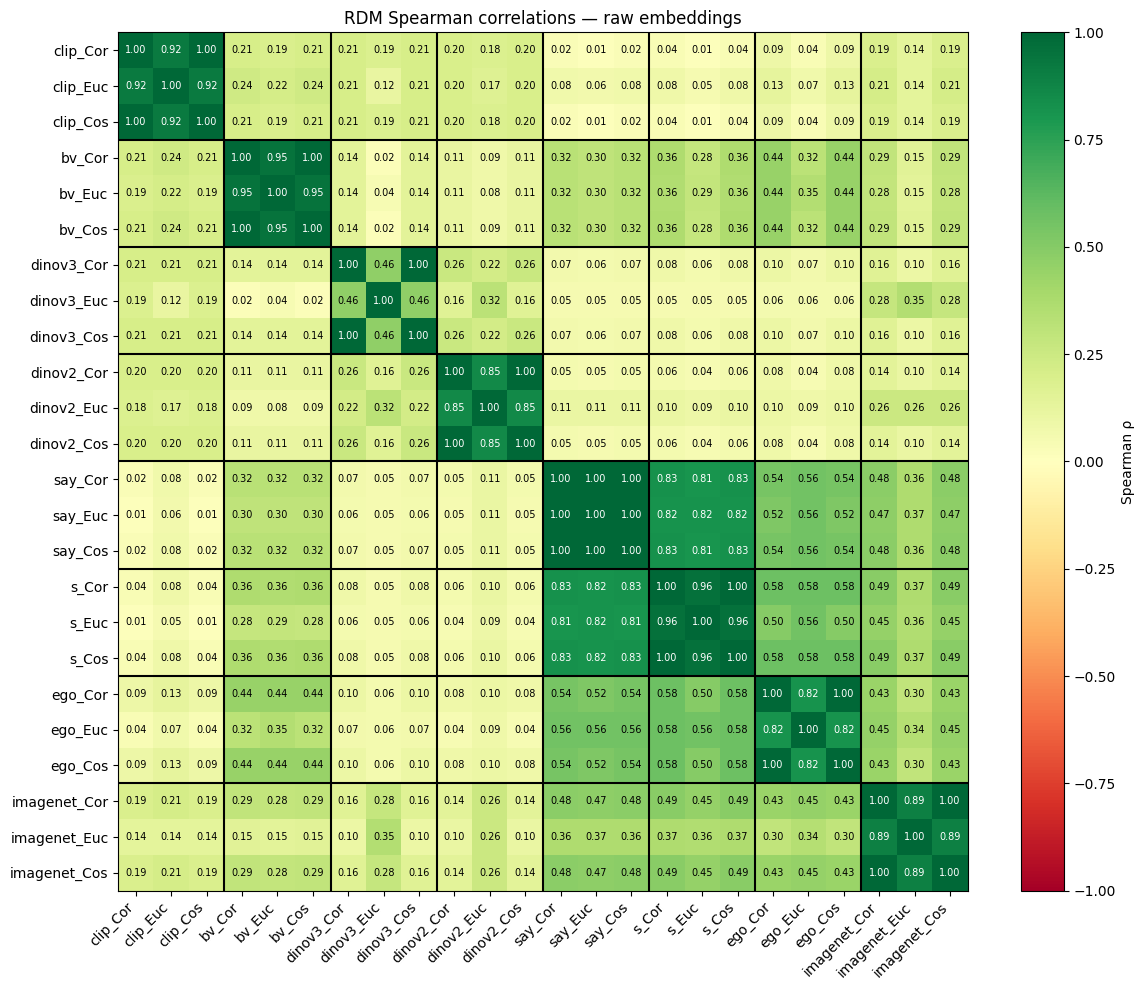

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def plot_corr_matrix(df_corr, keys, n_methods, title):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(df_corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

    # Ticks
    ax.set_xticks(np.arange(len(keys)))
    ax.set_yticks(np.arange(len(keys)))
    ax.set_xticklabels(keys, rotation=45, ha='right')
    ax.set_yticklabels(keys)

    # Annotate cells
    for i in range(len(keys)):
        for j in range(len(keys)):
            val = df_corr.values[i, j]
            color = 'white' if abs(val) > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=7)

    # Separator lines between models
    for i in range(n_methods, len(keys), n_methods):
        ax.axhline(i - 0.5, color='black', linewidth=1.5)
        ax.axvline(i - 0.5, color='black', linewidth=1.5)

    plt.colorbar(im, ax=ax, label='Spearman ρ')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    
plot_corr_matrix(df_corr_raw, keys, len(methods),
                 'RDM Spearman correlations — raw embeddings')


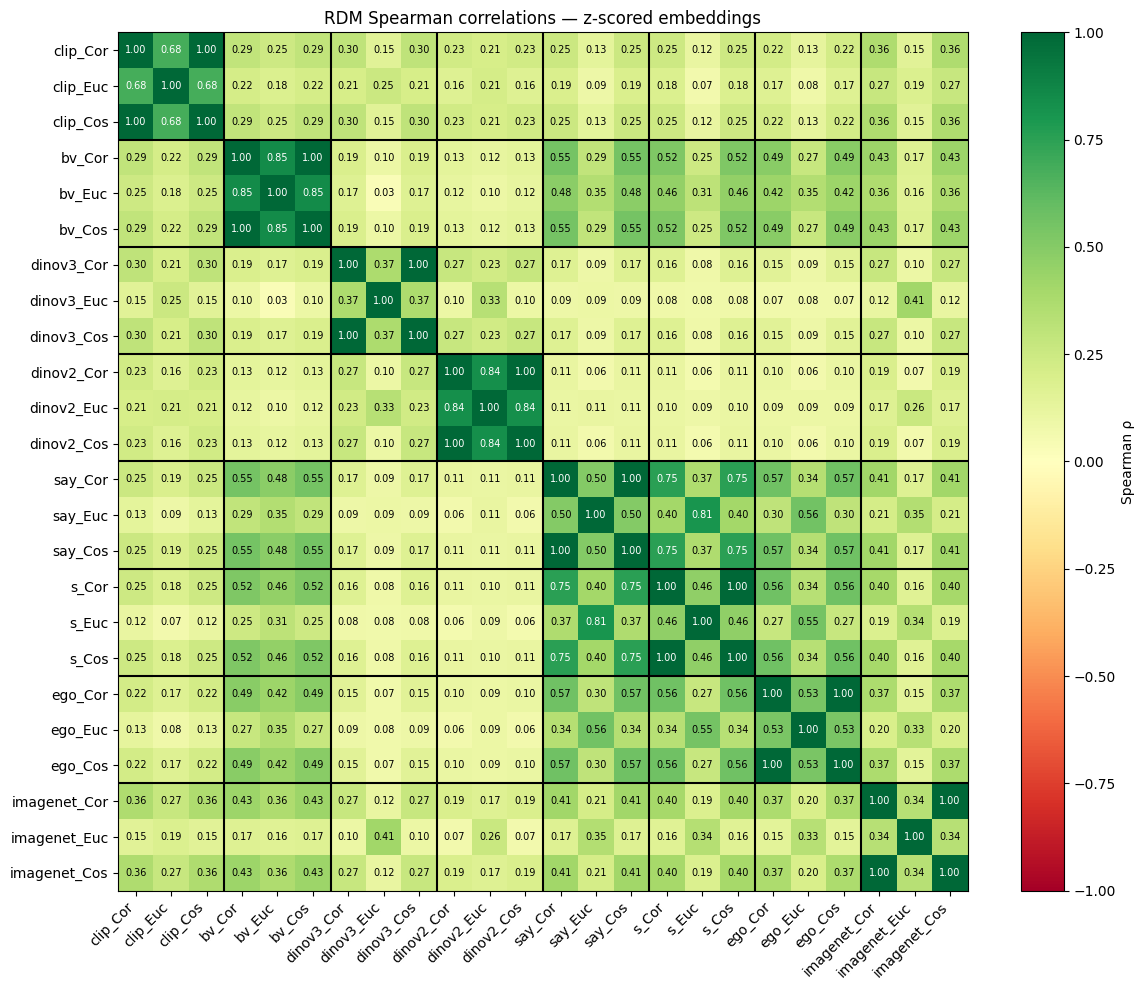

In [25]:
plot_corr_matrix(df_corr_z, keys, len(methods),
                 'RDM Spearman correlations — z-scored embeddings')